In [9]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D , MaxPooling2D,Flatten,BatchNormalization,Dropout
from tensorflow.keras.layers import RandomRotation,RandomZoom,RandomFlip
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2

train_dataset = keras.utils.image_dataset_from_directory(
    directory = 'C:/Users/HP/Desktop/archive/chest_xray/train',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 64,
    image_size =(150,150)
)
validation_dataset = keras.utils.image_dataset_from_directory(
    directory = 'C:/Users/HP/Desktop/archive/chest_xray/test',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 64,
    image_size =(150,150)
)

#Normalize
def process(image,label):
    image = tf.cast(image/149 , tf.float32)
    return image,label
train_dataset = train_dataset.map(process)
validation_dataset = validation_dataset.map(process) 

#Pretrained base model
base_model = MobileNetV2(
    weights='imagenet',
    include_top = False,
    input_shape = (150,150,3))
base_model.trainable = False

# CNN model
model = Sequential()

# Data augmentation layers
model.add(RandomFlip("horizontal", input_shape=(150,150,3)))  
model.add(RandomRotation(0.2))  
model.add(RandomZoom(0.2))      

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(150,150,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1,activation='sigmoid'))

model.summary()

Found 5216 files belonging to 2 classes.
Found 624 files belonging to 2 classes.


C:\Users\HP\AppData\Local\Temp\ipykernel_15272\3853556022.py:30: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)           │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_rotation_1 (RandomRotation)   │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_zoom_1 (RandomZoom)           │ (None, 150, 150, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 148, 148, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 72, 72, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 34, 34, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 128)                 │       4,735,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,837,569 (18.45 MB)

 Trainable params: 4,837,121 (18.45 MB)

 Non-trainable params: 448 (1.75 KB)

In [11]:
optimizer = Adam(learning_rate=0.0005)
model.compile(optimizer = optimizer,loss='binary_crossentropy',metrics=['accuracy'])
a = model.fit(train_dataset,epochs=10,validation_data = validation_dataset)

Epoch 1/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 1235s 15s/step - accuracy: 0.8579 - loss: 0.4359 - val_accuracy: 0.6250 - val_loss: 4.3172
Epoch 2/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 617s 7s/step - accuracy: 0.9041 - loss: 0.2557 - val_accuracy: 0.6250 - val_loss: 9.2700
Epoch 3/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 893s 11s/step - accuracy: 0.9168 - loss: 0.2214 - val_accuracy: 0.6250 - val_loss: 7.8670
Epoch 4/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 1030s 12s/step - accuracy: 0.9204 - loss: 0.2114 - val_accuracy: 0.6250 - val_loss: 6.5081
Epoch 5/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 741s 9s/step - accuracy: 0.9268 - loss: 0.1916 - val_accuracy: 0.6250 - val_loss: 3.7292
Epoch 6/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 1387s 17s/step - accuracy: 0.9362 - loss: 0.1757 - val_accuracy: 0.8141 - val_loss: 0.5356
Epoch 7/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 544s 7s/step - accuracy: 0.9298 - loss: 0.1855 - val_accuracy: 0.6378 - val_loss: 2.4912
Epoch 8/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 955s 12s/step - accuracy: 0.9404 - loss: 0.1647 - val_accuracy: 0.

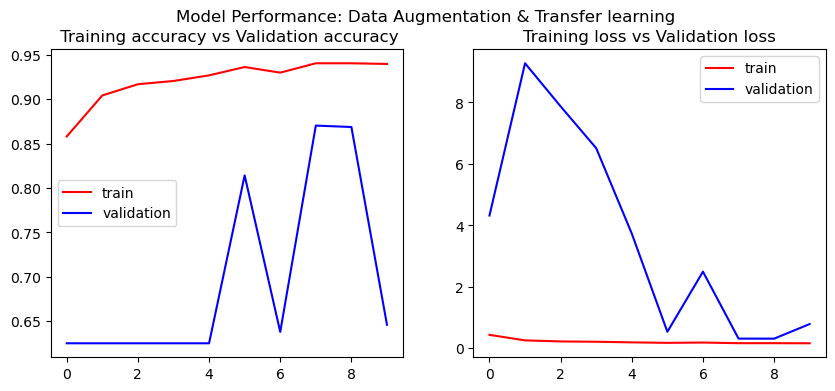

In [13]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1,2,figsize=(10,4))
ax[0].plot(a.history['accuracy'], color = 'red' , label = 'train')
ax[0].plot(a.history['val_accuracy'], color = 'blue' , label = 'validation')
ax[0].set_title(' Training accuracy vs Validation accuracy')

ax[1].plot(a.history['loss'], color = 'red' , label = 'train')
ax[1].plot(a.history['val_loss'], color = 'blue' , label = 'validation')
ax[1].set_title('Training loss vs Validation loss')
fig.suptitle('Model Performance: Data Augmentation & Transfer learning')
ax[0].legend()
ax[1].legend()

plt.show()
              

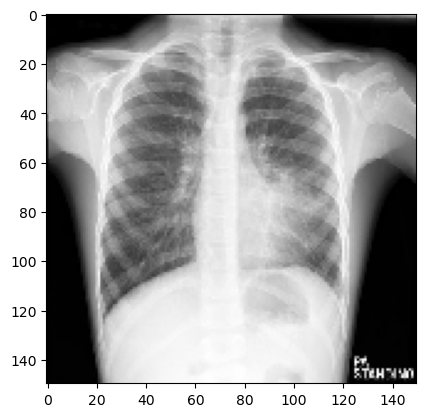

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


array([[0.98873055]], dtype=float32)

In [79]:
from tensorflow.keras.preprocessing import image
import numpy as np
img_path = 'Desktop/pneumonia_Xray.jpeg' 
test_img = image.load_img(img_path, target_size=(150,150))
img_arr = image.img_to_array(test_img)
img_arr = img_arr / 255
plt.imshow(img_arr)
plt.show()
model.predict(test_input)
